## Practice Lab 20: Convolutional Neural Networks
In this lab we will look at how Convolutional Neural Networks for classification and regression. \
Based on Chapter 14 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice20_CNN.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [81]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# Add for GPU BEFORE JSON
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)
####################################

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

Added two functions for plotting

In [82]:
def plot_image(image):
    plt.imshow(image, cmap="gray", interpolation="nearest")
    plt.axis("off")

def plot_color_image(image):
    plt.imshow(image, interpolation="nearest")
    plt.axis("off")

### Exercise 1
Load the two images below and apply a vertical and a horizontal filter.\
Check all dimensions. Then plot one row of one of the figures before and after convolutions. \
Show how the convolution with the horizontal filter produces a smoothing along the rows.

In [83]:
import numpy as np
from sklearn.datasets import load_sample_image
# Load sample images
china = load_sample_image("china.jpg") / 255
flower = load_sample_image("flower.jpg") / 255
images = np.array([china, flower])
print("batch_size, height, width, channels",images.shape)
batch_size, height, width, channels = images.shape
# Create 2 filters
filters = np.zeros(shape=(7, 7, channels, 2), dtype=np.float32)
filters[:, 3, :, 0] = 1  # vertical line
filters[3, :, :, 1] = 1  # horizontal line

batch_size, height, width, channels (2, 427, 640, 3)


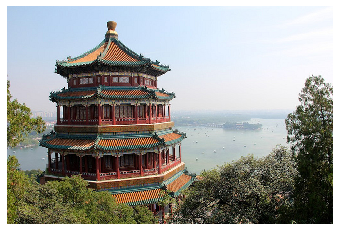

In [84]:
plot_image(china)

In [85]:
print(china.shape)

(427, 640, 3)


In [86]:
print(flower.shape)

(427, 640, 3)


Text(0.5, 1.0, 'column')

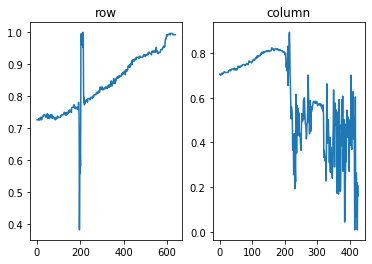

In [87]:
# show a row and a column of the original picture
plt.subplot(121);plt.plot(china[50,:,0]);plt.title('row')
plt.subplot(122);plt.plot(china[:,50,0]);plt.title('column')

In [88]:
print(images.shape)

(2, 427, 640, 3)


In [89]:
print(filters.shape)

(7, 7, 3, 2)


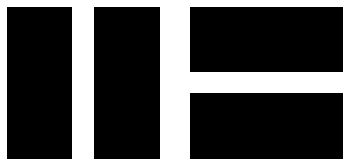

In [90]:
plt.subplot(121);plot_image(filters[:,:,:,0])
plt.subplot(122);plot_image(filters[:,:,:,1])

In [91]:
outputs = tf.nn.conv2d(images, filters, strides=1, padding="SAME")

In [92]:
print(outputs.shape)

(2, 427, 640, 2)


In [93]:
print(images.shape)

(2, 427, 640, 3)


In [94]:
print(filters.shape)

(7, 7, 3, 2)


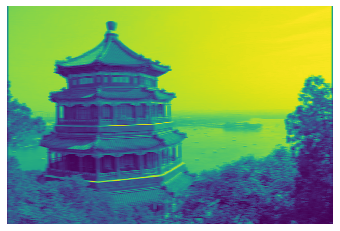

In [95]:
plot_color_image(outputs[0,:,:,1])

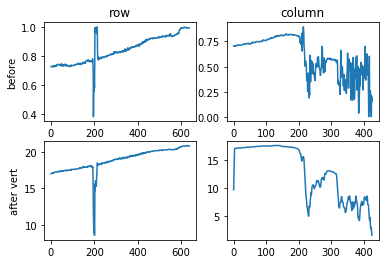

In [96]:
# plot a row and a column before and after the vertical filter
plt.subplot(221);plt.plot(china[50,:,0]);plt.title('row');plt.ylabel('before')
plt.subplot(222);plt.plot(china[:,50,0]);plt.title('column')
plt.subplot(223);plt.plot(outputs[0,50,:,0]);plt.ylabel('after vert')
plt.subplot(224);plt.plot(outputs[0,:,50,0]);

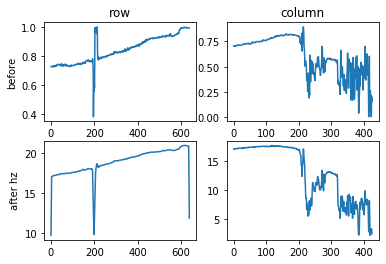

In [97]:
# plot a row and a column after the horizontal filter

plt.subplot(221);plt.plot(china[50,:,0]);plt.title('row');plt.ylabel('before')
plt.subplot(222);plt.plot(china[:,50,0]);plt.title('column')
plt.subplot(223);plt.plot(outputs[0,50,:,1]);plt.ylabel('after hz')
plt.subplot(224);plt.plot(outputs[0,:,50,1])

0
1
2


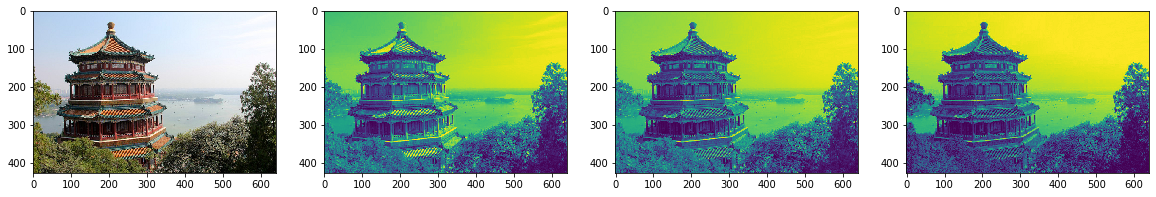

In [126]:
plt.figure(figsize=(20,20))
plt.subplot(141),plt.imshow(china)
for i in range(3):
    print(i)
    plt.subplot(142+i);plt.imshow(china[:,:,i]);


0
1


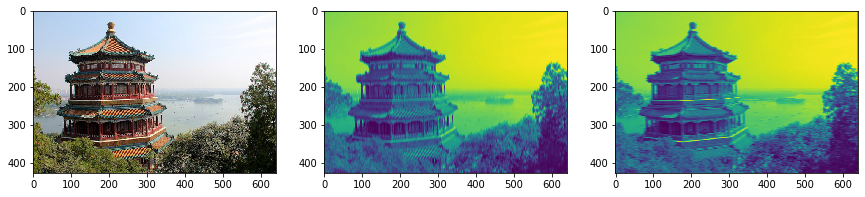

In [128]:
outputs = tf.nn.conv2d(images, filters, strides=1, padding="SAME")
plt.figure(figsize=(20,20))
plt.subplot(141),plt.imshow(china)
for i in range(2):
    print(i)
    plt.subplot(142+i);plt.imshow(outputs[0,:,:,i]);


### Exercise 2
Write conv2d for the mnist data set and compare with the 1D neural network we did in a previous lab.\
To treat each digit as an image, you need to add the feature axis, 1 in this case because it is black-white image.

In [18]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [19]:
print(X_train.shape)

(55000, 28, 28, 1)


In [20]:
print(X_valid.shape)
print(X_test.shape)

(5000, 28, 28, 1)
(10000, 28, 28, 1)


In [53]:
model=keras.models.Sequential([
    keras.layers.Conv2D(64, kernel_size=(7,7), activation='relu', padding='SAME',input_shape=[28,28,1]),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(128, kernel_size=(5,5), activation='relu', padding='SAME'),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(256, kernel_size=(3,3), activation='relu', padding='SAME'),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')    
])

Alternatively, for long stacks of layers, we can create a default

In [21]:
#create a default layer to avoid repeating
from functools import partial
DefaultConv2D = partial(keras.layers.Conv2D, kernel_size=(3,3), activation='relu',padding='SAME')

In [22]:
model=keras.models.Sequential([
    DefaultConv2D(64, kernel_size=(7,7), input_shape=[28,28,1]),
    keras.layers.MaxPooling2D(),
    DefaultConv2D(128, kernel_size=(5,5)),
    keras.layers.MaxPooling2D(),
    DefaultConv2D(256),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')    
])

In [54]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='SGD',metrics=["accuracy"])

In [55]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 28, 28, 64)        3200      
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 14, 14, 64)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 14, 14, 128)       204928    
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 7, 7, 128)         0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 7, 7, 256)         295168    
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 3, 3, 256)         0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 2304)             

In [56]:
history=model.fit(X_train,y_train,epochs=10,validation_data=(X_valid,y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 7s 118us/sample - loss: 0.8362 - accuracy: 0.7334 - val_loss: 0.1260 - val_accuracy: 0.9638
Epoch 2/10
55000/55000 [==============================] - 6s 106us/sample - loss: 0.2532 - accuracy: 0.9302 - val_loss: 0.0693 - val_accuracy: 0.9800
Epoch 3/10
55000/55000 [==============================] - 6s 105us/sample - loss: 0.1686 - accuracy: 0.9560 - val_loss: 0.0597 - val_accuracy: 0.9830
Epoch 4/10
55000/55000 [==============================] - 6s 105us/sample - loss: 0.1306 - accuracy: 0.9656 - val_loss: 0.0473 - val_accuracy: 0.9872
Epoch 5/10
55000/55000 [==============================] - 6s 105us/sample - loss: 0.1086 - accuracy: 0.9726 - val_loss: 0.0484 - val_accuracy: 0.9878
Epoch 6/10
55000/55000 [==============================] - 6s 106us/sample - loss: 0.0890 - accuracy: 0.9774 - val_loss: 0.0392 - val_accuracy: 0.9896
Epoch 7/10
55000/55000 [===========================

In [57]:
model.evaluate(X_test,y_test)

10000/10000 [==============================] - 1s 61us/sample - loss: 0.0348 - accuracy: 0.9899


[0.03476162396185342, 0.9899]

In [58]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

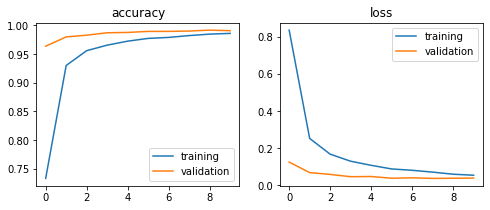

In [59]:
plt.figure(figsize=(8,3))
plt.subplot(121),plt.plot(history.history['accuracy'],label='training');plt.plot(history.history['val_accuracy'],label='validation');plt.title('accuracy')
plt.legend()
plt.subplot(122),plt.plot(history.history['loss'],label='training');plt.plot(history.history['val_loss'],label='validation');plt.title('loss')
plt.legend()

## Compare with 1D network
Now let us compare with the dense network we have been doing before

In [64]:
model1d = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal",activation="relu"),
    keras.layers.Dense(100, kernel_initializer="he_normal",activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])
model1d.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [65]:
model1d.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_5 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_17 (Dense)             (None, 300)               235500    
_________________________________________________________________
dense_18 (Dense)             (None, 100)               30100     
_________________________________________________________________
dense_19 (Dense)             (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [66]:
print(X_train[:,:,:,0].shape)
print(y_train.shape)

(55000, 28, 28)
(55000,)


In [67]:


history1d=model1d.fit(X_train[:,:,:,0],y_train,epochs=10,validation_data=(X_valid[:,:,:,0],y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 3s 62us/sample - loss: 1.1542 - accuracy: 0.6685 - val_loss: 0.5540 - val_accuracy: 0.8632
Epoch 2/10
55000/55000 [==============================] - 3s 55us/sample - loss: 0.5194 - accuracy: 0.8596 - val_loss: 0.3601 - val_accuracy: 0.9072
Epoch 3/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.3915 - accuracy: 0.8905 - val_loss: 0.2949 - val_accuracy: 0.9212
Epoch 4/10
55000/55000 [==============================] - 3s 55us/sample - loss: 0.3317 - accuracy: 0.9049 - val_loss: 0.2592 - val_accuracy: 0.9282
Epoch 5/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.2947 - accuracy: 0.9143 - val_loss: 0.2365 - val_accuracy: 0.9372
Epoch 6/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.2686 - accuracy: 0.9215 - val_loss: 0.2207 - val_accuracy: 0.9408
Epoch 7/10
55000/55000 [==============================] -

In [68]:
model1d.evaluate(X_test[:,:,:,0],y_test)

10000/10000 [==============================] - 0s 44us/sample - loss: 0.2278 - accuracy: 0.9351


[0.22784268756359816, 0.9351]

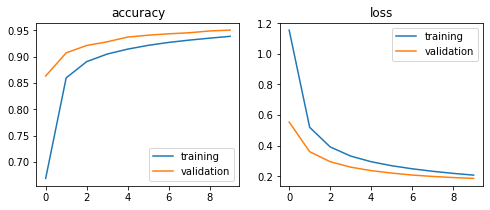

In [69]:
plt.figure(figsize=(8,3))
plt.subplot(121),plt.plot(history1d.history['accuracy'],label='training');plt.plot(history1d.history['val_accuracy'],label='validation');plt.title('accuracy')
plt.legend()
plt.subplot(122),plt.plot(history1d.history['loss'],label='training');plt.plot(history1d.history['val_loss'],label='validation');plt.title('loss')
plt.legend();

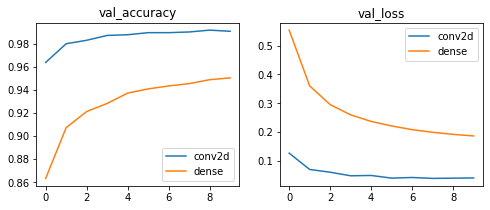

In [70]:
plt.figure(figsize=(8,3))
plt.subplot(121),plt.plot(history.history['val_accuracy'],label='conv2d');plt.plot(history1d.history['val_accuracy'],label='dense');plt.title('val_accuracy')
plt.legend()
plt.subplot(122),plt.plot(history.history['val_loss'],label='conv2d');plt.plot(history1d.history['val_loss'],label='dense');plt.title('val_loss')
plt.legend()

In [71]:
ntest=20;
y_predict2d=model.predict(X_test[:ntest])

In [72]:
y_predict1d=model1d.predict(X_test[:ntest,:,:,0])

In [73]:
print(y_test[:ntest])

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [74]:
print(y_predict2d.shape)

(20, 10)


In [75]:
print(y_predict1d.shape)

(20, 10)


In [76]:
print(['index','true','pred2d','pred1d'])
[print(i,'\t',y_test[i], '\t',y_predict2d[i,:].argmax(), '\t',y_predict1d[i,:].argmax()) for i in range(0,ntest)];

['index', 'true', 'pred2d', 'pred1d']
0 	 7 	 7 	 7
1 	 2 	 2 	 2
2 	 1 	 1 	 1
3 	 0 	 0 	 0
4 	 4 	 4 	 4
5 	 1 	 1 	 1
6 	 4 	 4 	 4
7 	 9 	 9 	 4
8 	 5 	 5 	 5
9 	 9 	 9 	 9
10 	 0 	 0 	 0
11 	 6 	 6 	 6
12 	 9 	 9 	 9
13 	 0 	 0 	 0
14 	 1 	 1 	 1
15 	 5 	 5 	 5
16 	 9 	 9 	 9
17 	 7 	 7 	 7
18 	 3 	 3 	 5
19 	 4 	 4 	 4


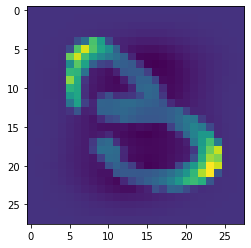

In [78]:
[plt.imshow(X_test[18,:,:,0]) for i in range(0,10)];

Exercise 3: Fashion data set

In [129]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [130]:
from functools import partial

DefaultConv2D = partial(keras.layers.Conv2D,
                        kernel_size=3, activation='relu', padding="SAME")

model = keras.models.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

In [131]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])

## For each layer, the size of the filters can be calculated as

$\sqrt((param-nfeatures)/nfeatures)$

Subtract nfeatures for the biases (they count as one parameter per feature) and filters are 2D $(nfilter^2)$

Example, below, 
conv2d_3  we have
sqrt((3200-64)/64)=7
conv2d_7, we have
sqrt((590080-256)/256)=48



In [132]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_6 (Conv2D)            (None, 28, 28, 64)        3200      
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 14, 14, 64)        0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 14, 14, 128)       73856     
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 14, 14, 128)       147584    
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 7, 7, 128)         0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 7, 7, 256)         295168    
_________________________________________________________________
conv2d_10 (Conv2D)           (None, 7, 7, 256)        

In [133]:
history = model.fit(X_train, y_train, epochs=10, validation_data=[X_valid, y_valid])



Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 11s 206us/sample - loss: 0.6872 - accuracy: 0.7635 - val_loss: 0.3829 - val_accuracy: 0.8682
Epoch 2/10
55000/55000 [==============================] - 10s 181us/sample - loss: 0.4171 - accuracy: 0.8603 - val_loss: 0.3154 - val_accuracy: 0.8806
Epoch 3/10
55000/55000 [==============================] - 10s 177us/sample - loss: 0.3651 - accuracy: 0.8783 - val_loss: 0.3302 - val_accuracy: 0.8726
Epoch 4/10
55000/55000 [==============================] - 10s 178us/sample - loss: 0.3231 - accuracy: 0.8905 - val_loss: 0.3139 - val_accuracy: 0.8826
Epoch 5/10
55000/55000 [==============================] - 10s 177us/sample - loss: 0.3085 - accuracy: 0.8953 - val_loss: 0.2789 - val_accuracy: 0.8964
Epoch 6/10
55000/55000 [==============================] - 10s 178us/sample - loss: 0.2935 - accuracy: 0.9004 - val_loss: 0.2809 - val_accuracy: 0.9008
Epoch 7/10
55000/55000 [=====================

In [134]:
score = model.evaluate(X_test, y_test)

10000/10000 [==============================] - 1s 71us/sample - loss: 0.3072 - accuracy: 0.8971


In [135]:
X_new = X_test[:10] # pretend we have new images
y_pred = model.predict(X_new)

In [140]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

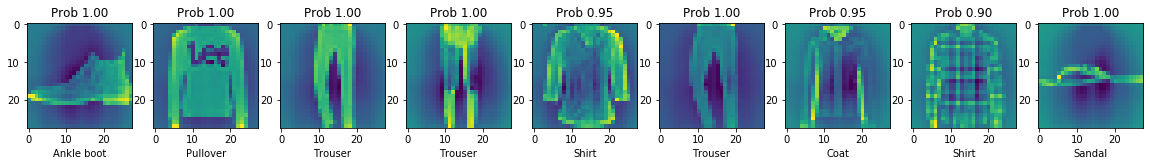

In [152]:
plt.figure(figsize=(20,20))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_new[i].reshape(28,28));
    maxp=np.argmax(y_pred[i])
    plt.title('Prob %.2f'%y_pred[i][maxp])
    plt.xlabel(class_names[maxp])